# Pipeline ambx — Testes por Etapa

Este notebook executa e visualiza cada etapa da pipeline do framework **ambx** (*Ambient Access*), permitindo inspecionar os resultados intermediários antes de integrar tudo no script `pipeline.py`.

**Etapas:**
1. **1a — Malha Territorial**: geração da grade de análise (hexagonal/quadrada)
2. **1b — Pontos de Interesse**: coleta de POIs categorizados do OSM
3. **1c — Rede Viária**: construção do grafo de deslocamento
4. **1d — Vinculação Malha ↔ Rede**: snapping dos centróides aos nós do grafo
5. **2 — Roteamento A\*** : matriz origem-destino com caminhos mínimos (A* com heurística euclidiana)

In [19]:
# --- Setup: path e imports ---
import sys
sys.path.insert(0, "../scripts")


from ambx.grid import generate_grid, GridFormat
from ambx.network import (
    add_travel_time,
    get_network,
    get_graph_edges,
    project_network,
    snap_grid_to_network,
)
from ambx.pois import get_pois
from ambx.routing import snap_pois_to_network, routing_matrix

print("✓ Todos os módulos importados com sucesso.")

✓ Todos os módulos importados com sucesso.


## Parâmetros

Defina aqui a localidade e os parâmetros da análise. Altere `LOCATION` para testar com outras cidades.

In [22]:
# --- Parâmetros da análise ---
LOCATION = "Compiegne, Hauts de France, France"
GRID_FORMAT = GridFormat.HEXAGON
CELL_SIZE = 200        # metros (raio do hexágono ou lado do quadrado)
POI_BUFFER = 2000      # metros — captura serviços de cidades vizinhas
NETWORK_TYPE = "walk"  # walk, bike, drive
WALK_SPEED_KPH = 5.0   # km/h

print(f"Localidade : {LOCATION}")
print(f"Malha      : {GRID_FORMAT.value}, {CELL_SIZE}m")
print(f"Buffer POI : {POI_BUFFER}m")
print(f"Rede       : {NETWORK_TYPE} ({WALK_SPEED_KPH} km/h)")

Localidade : Compiegne, Hauts de France, France
Malha      : hexagon, 200m
Buffer POI : 2000m
Rede       : walk (5.0 km/h)


## Etapa 1a — Malha Territorial

Geração da grade de células (hexágonos ou quadrados) que cobre o contorno administrativo da localidade.

In [23]:
# --- Gerar malha territorial ---
grid = generate_grid(LOCATION, grid_format=GRID_FORMAT, cell_size=CELL_SIZE)
print(f"Células geradas: {len(grid)}")
print(f"CRS: {grid.crs}")
print(f"Área total coberta: {grid.to_crs(grid.estimate_utm_crs()).area.sum() / 1e6:.2f} km²")

Células geradas: 571
CRS: EPSG:4326
Área total coberta: 59.34 km²


## Etapa 1b — Pontos de Interesse

Coleta de destinos do OpenStreetMap categorizados em saúde, educação, transporte e alimentação.

In [24]:
# --- Coletar Pontos de Interesse ---
pois = get_pois(LOCATION, buffer=POI_BUFFER)
print(f"Total de POIs: {len(pois)}")
print(f"Categorias:\n{pois['category'].value_counts().to_string()}")

Total de POIs: 517
Categorias:
category
transportation    267
education         114
food               84
health             52


## Etapa 1c — Rede Viária

Construção do grafo de deslocamento a partir do OpenStreetMap, projeção para CRS métrico e cálculo do tempo de percurso nas arestas.

In [25]:
# --- Construir grafo viário ---
print("Baixando grafo do OSM...")
graph = get_network(LOCATION, network_type=NETWORK_TYPE)
print(f"Nós (original): {graph.number_of_nodes()}")
print(f"Arestas (original): {graph.number_of_edges()}")

# Projetar para UTM
print("Projetando para UTM...")
graph = project_network(graph)
print(f"CRS do grafo projetado: {graph.graph.get('crs', 'N/A')}")

# Adicionar tempo de percurso
graph = add_travel_time(graph, speed_kph=WALK_SPEED_KPH)
print(f"Tempo de percurso adicionado (speed={WALK_SPEED_KPH} km/h)")

# Visualizar arestas
edges = get_graph_edges(graph)
print(f"Extensão total da rede: {edges.length.sum() / 1000:.1f} km")

Baixando grafo do OSM...
Nós (original): 4887
Arestas (original): 13830
Projetando para UTM...
CRS do grafo projetado: EPSG:32631
Tempo de percurso adicionado (speed=5.0 km/h)
Extensão total da rede: 1146.8 km


## Etapa 1d — Vinculação Malha ↔ Rede

Snapping dos centróides de cada célula da malha ao nó mais próximo do grafo viário. Células muito distantes da rede são descartadas.

In [26]:
# --- Vincular malha à rede ---
snapped = snap_grid_to_network(grid, graph, projected=False, max_distance=1000)

print(f"Células originais      : {len(grid)}")
print(f"Células vinculadas     : {len(snapped)}")
print(f"Taxa de vinculação     : {len(snapped) / len(grid) * 100:.1f}%")
print(f"Distância média snap   : {snapped['snap_distance'].mean():.1f} m")
print(f"Distância máxima snap  : {snapped['snap_distance'].max():.1f} m")

# Células não vinculadas (se houver limite de distância)
if len(snapped) < len(grid):
    lost = len(grid) - len(snapped)
    print(f"Células descartadas    : {lost} ({lost / len(grid) * 100:.1f}%)")

Células originais      : 571
Células vinculadas     : 571
Taxa de vinculação     : 100.0%
Distância média snap   : 132.4 m
Distância máxima snap  : 525.9 m


## Etapa 2 — Roteamento A*

Cálculo da matriz origem-destino: para cada célula da malha, encontra o caminho mínimo até cada POI usando o algoritmo **A\*** com heurística de distância euclidiana. O custo das arestas é o tempo de percurso (`travel_time`).

Vinculando POIs à rede...
POIs vinculados: 517 / 517
Distância média snap: 302.5 m

Estimativa de pares A*: 571 células × 4 categorias × 3 = 6852
(matriz completa seria: 571 × 517 = 295207)

  [seleção] célula 1/571, 12 pares acumulados
  [seleção] célula 50/571, 600 pares acumulados
  [seleção] célula 100/571, 1200 pares acumulados
  [seleção] célula 150/571, 1800 pares acumulados
  [seleção] célula 200/571, 2400 pares acumulados
  [seleção] célula 250/571, 3000 pares acumulados
  [seleção] célula 300/571, 3600 pares acumulados
  [seleção] célula 350/571, 4200 pares acumulados
  [seleção] célula 400/571, 4800 pares acumulados
  [seleção] célula 450/571, 5400 pares acumulados
  [seleção] célula 500/571, 6000 pares acumulados
  [seleção] célula 550/571, 6600 pares acumulados

  Total de pares: 6852
  Executando A* em paralelo (n_jobs=38, chunksize=45)...
  [A*] 68/6852 pares concluídos
  [A*] 136/6852 pares concluídos
  [A*] 204/6852 pares concluídos
  [A*] 272/6852 pares concluídos
  [

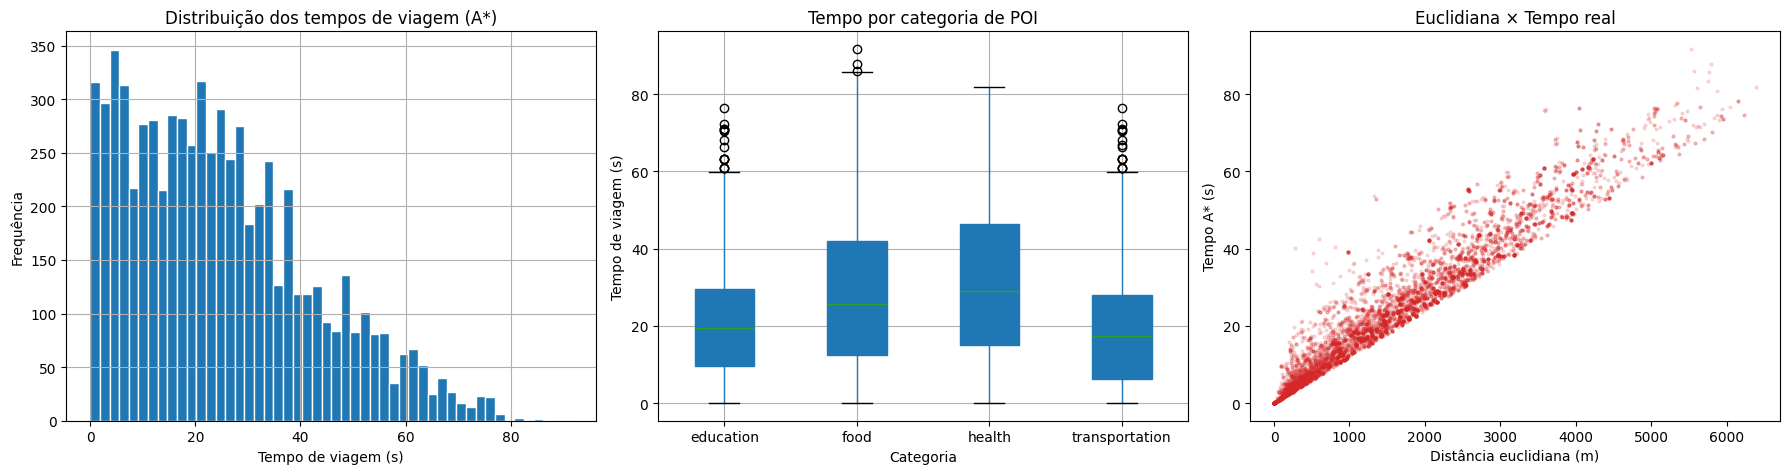

,cell_idx,poi_idx,euclidean_dist,travel_time,poi_category,poi_name
0,0.0,12,61.386889,0.736326,health,Pharmacie de la Forêt
1,0.0,51,2271.946732,48.391295,health,Centre Psychothérapique Henri Theillou
2,0.0,32,2297.815611,48.850060,health,Urgences Médecins Oise
3,0.0,84,61.386889,0.736326,education,École maternelle Les Bruyères
4,0.0,85,61.386889,0.736326,education,École élémentaire Les Bruyéres
5,0.0,158,61.386889,0.736326,education,NaN
6,0.0,257,61.386889,0.736326,transportation,Matra Lecuru
7,0.0,393,61.386889,0.736326,transportation,Nord
8,0.0,394,61.386889,0.736326,transportation,Nord
9,0.0,465,61.386889,0.736326,food,Boulangerie Joseph


In [27]:
# --- Roteamento A*: K vizinhos mais próximos por categoria ---
import time

K_NEAREST = 3   # quantos POIs mais próximos por categoria considerar
N_JOBS = 38

print("Vinculando POIs à rede...")
pois_snapped = snap_pois_to_network(pois, graph)
print(f"POIs vinculados: {len(pois_snapped)} / {len(pois)}")
print(f"Distância média snap: {pois_snapped['snap_distance'].mean():.1f} m")

# Estatísticas de quantos pares serão calculados
cats = pois_snapped["category"].nunique()
est_pairs = len(snapped) * cats * K_NEAREST
print(f"\nEstimativa de pares A*: {len(snapped)} células × {cats} categorias × {K_NEAREST} = {est_pairs}")
print(f"(matriz completa seria: {len(snapped)} × {len(pois_snapped)} = {len(snapped) * len(pois_snapped)})")
print()

t0 = time.perf_counter()
# snapped_sample = snapped.sample(n=10, random_state=42)  # amostra para teste
matrix = routing_matrix(snapped, pois_snapped, graph, k_nearest=K_NEAREST, speed_kph=WALK_SPEED_KPH, n_jobs=N_JOBS)
elapsed = time.perf_counter() - t0

print(f"\n✓ Matriz concluída em {elapsed:.1f}s ({len(matrix) / elapsed:.0f} pares/s)")

# --- Resumo da matriz ---
reachable = matrix["travel_time"].notna().sum()
unreachable = matrix["travel_time"].isna().sum()
print(f"\nPares alcançáveis:   {reachable} ({reachable / len(matrix) * 100:.1f}%)")
print(f"Pares inalcançáveis: {unreachable} ({unreachable / len(matrix) * 100:.1f}%)")

print(f"\nTempo de viagem (alcançáveis):")
tt = matrix.loc[matrix["travel_time"].notna(), "travel_time"]
print(f"  Média:   {tt.mean() / 60:.1f} min")
print(f"  Mediana: {tt.median() / 60:.1f} min")
print(f"  Mínimo:  {tt.min() / 60:.1f} min")
print(f"  Máximo:  {tt.max() / 60:.1f} min")

print(f"\nDistância euclidiana vs tempo de viagem:")
print(f"  Correlação: {matrix['euclidean_dist'].corr(matrix['travel_time']):.3f}")

# --- Visualização: distribuição dos tempos por categoria ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
matrix[matrix["travel_time"].notna()]["travel_time"].hist(
    bins=50, ax=axes[0], color="#1f77b4", edgecolor="white"
)
axes[0].set_xlabel("Tempo de viagem (s)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição dos tempos de viagem (A*)")

# Boxplot por categoria
matrix.boxplot(
    column="travel_time",
    by="poi_category",
    ax=axes[1],
    patch_artist=True,
)
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Tempo de viagem (s)")
axes[1].set_title("Tempo por categoria de POI")

# Scatter: euclidiana vs tempo
matrix.plot.scatter(
    x="euclidean_dist", y="travel_time",
    ax=axes[2], alpha=0.15, s=4, color="#d62728"
)
axes[2].set_xlabel("Distância euclidiana (m)")
axes[2].set_ylabel("Tempo A* (s)")
axes[2].set_title("Euclidiana × Tempo real")

fig.suptitle("")
plt.tight_layout()
plt.show()

# Primeiras linhas da matriz
matrix.head(10)


## Mapa das Células Sample — Tempo Médio de Acesso

Visualização espacial das células amostradas, coloridas pelo tempo médio de acesso (média dos tempos de viagem A* para os POIs mais próximos de cada categoria).

In [ ]:
# Calcular tempo médio de acesso por célula
avg_travel_time = (
    matrix.groupby("cell_idx")["travel_time"]
    .mean()
    .reset_index()
    .rename(columns={"travel_time": "avg_travel_time"})
)

# Pegar geometrias das células sample (do grid original)
# snapped_sample tem o mesmo index do grid original
cells = grid.loc[snapped.index].copy()
cells["cell_idx"] = cells.index

# Juntar com os tempos médios
cells_plot = cells.merge(avg_travel_time, on="cell_idx", how="left")

cells_plot.explore(column="avg_travel_time", cmap="YlOrRd", legend=True)

cells_plot.to_file("cells_travel_time.geojson", driver="GeoJSON")

## Resumo da Modelagem Territorial

Ao final destas 5 etapas, temos todos os elementos necessários para a análise de acessibilidade:

| Elemento | Descrição | Status |
|----------|-----------|:------:|
| **Malha** | Grade de células de análise | ✅ |
| **POIs** | Destinos categorizados (saúde, educação, transporte, alimentação) | ✅ |
| **Rede** | Grafo viário com tempos de percurso | ✅ |
| **Snapping** | Mapeamento célula → nó da rede | ✅ |
| **Routing (A\*)** | Matriz origem-destino com caminhos mínimos | ✅ |

**Próximas etapas:**
- **`environment`** — carregamento de camadas ambientais (rasters, polígonos de inundação)
- **`penalties`** — penalização das arestas por condicionantes ambientais
- **`indicators`** — cálculo de PTh, Índice G e F15